# What is Thresholding?

    - Thresholding = separating important part from unimportant part

    - Simple Rule:

        - If pixel < threshold → make it black (0)

        - If pixel ≥ threshold → make it white (255)

    - Layman Example

        - Imagine:

            - You are checking exam marks

            - Threshold = 50

            - Below 50 → Fail (0)

            - Above 50 → Pass (255)

            - You just separated students into 2 groups

# Why Thresholding?

    - Separate object from background

    - Make image easier to analyze

    - Convert image → binary (black & white)

    - Example (Image)

        - Grayscale pixels:

            - [20, 50, 120, 180, 250]

            - Threshold = 100

        - Result:

            - [0, 0, 255, 255, 255]

        - ✔ Dark → black
        - ✔ Bright → white

# Simple Thresholding (Global)

    - Same threshold for whole image

# Types (VERY IMPORTANT)
    - THRESH_BINARY

        - Normal rule

          - < threshold → 0

          - ≥ threshold → 255

    - THRESH_BINARY_INV

        - Opposite

            - < threshold → 255

            - ≥ threshold → 0

            - Like reversing black & white

    - THRESH_TRUNC

        - Limit values

            - threshold → become threshold

            - Others remain same

    - THRESH_TOZERO

        - Remove dark pixels

            - < threshold → 0

            - ≥ threshold → keep original

    - THRESH_TOZERO_INV

        - Remove bright pixels

            - ≥ threshold → 0

            - < threshold → keep original

# Easy Analogy for Types
    - Binary : 	Pass / Fail
    - Binary_INV :	Fail / Pass
    - Trunc	Cap : maximum value
    - ToZero :	Remove weak signals
    - ToZero_INV :	Remove strong signals

#Problem with Simple Threshold

    - Works only when lighting is same everywhere

    - If image has:

        - shadows

        - bright areas

    - It fails

# Adaptive Thresholding

    - Different threshold for different areas

        - Layman Example

            - Imagine:

                - In sunlight → threshold = 150

                - In shadow → threshold = 80

            - Each area treated differently

    -  Types:
        - MEAN
            - Average of neighbors

        - GAUSSIAN

            - Weighted average (center more important)

# Otsu’s Thresholding (Automatic)

    - You don’t choose threshold

        - OpenCV finds best value automatically

        - Layman Example

            - Imagine:

                - Students naturally form 2 groups:

                    - weak

                    - strong

        - Otsu automatically finds the best cutoff

    - When image has 2 clear groups (dark + bright)

# Key Difference

    - Simple :	Fixed
    - Adaptive :	Changes per region
    - Otsu :	Automatically calculated

# Visual Understanding
    - Even lighting :	Simple
    - Uneven lighting :	Adaptive
    - Unknown threshold :	Otsu

# Adding Border (copyMakeBorder)

    - Adds border around image

    - Types:
        - Constant

            - Add solid color

            - value=(0,255,0) → green border
        - Reflect

            - Mirror image at edges

        - Replicate

            - Repeat edge pixels

        - Example

            - Imagine photo:

                - Constant → frame around picture

                - Reflect → mirror edges

                - Replicate → stretch edges

# Final Summary 

    - Thresholding = convert image → black & white

        - Three main types:

            - Simple → same threshold

            - Adaptive → local threshold

            - Otsu → automatic threshold

# Super Easy Memory Trick

    - Simple = one rule for all

    - Adaptive = rule changes by area

    - Otsu = system decides rule

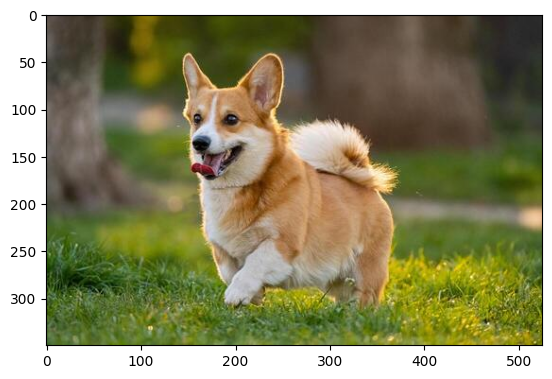

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("0_data/dog_img1.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img)

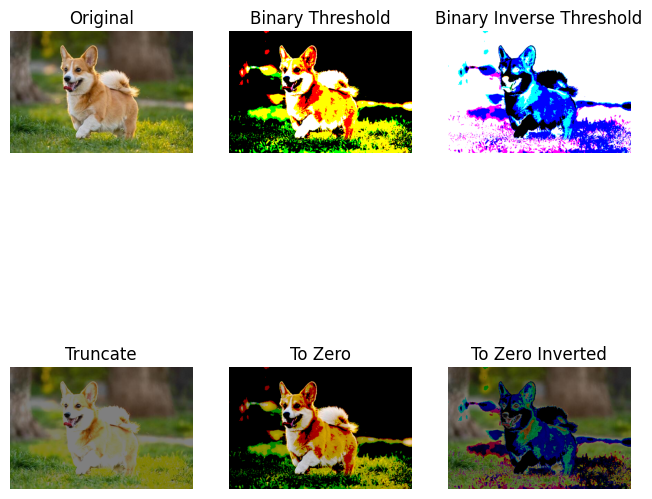

In [8]:
# Apply thresholds

new_img, thresh1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
new_img, thresh2 = cv.threshold(img, 127, 255, cv.THRESH_BINARY_INV)
new_img, thresh3 = cv.threshold(img, 127, 255, cv.THRESH_TRUNC)
new_img, thresh4 = cv.threshold(img, 127, 255, cv.THRESH_TOZERO)
new_img, thresh5 = cv.threshold(img, 127, 255, cv.THRESH_TOZERO_INV)

# Display the results
titles = ["Original", "Binary Threshold", "Binary Inverse Threshold", 
"Truncate", "To Zero", "To Zero Inverted"]
data = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

# plot
plt.figure(figsize= (8, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(data[i], cmap='gray', vmin = 0, vmax = 255)
    plt.title(titles[i])
    plt.axis('off')
plt.show()

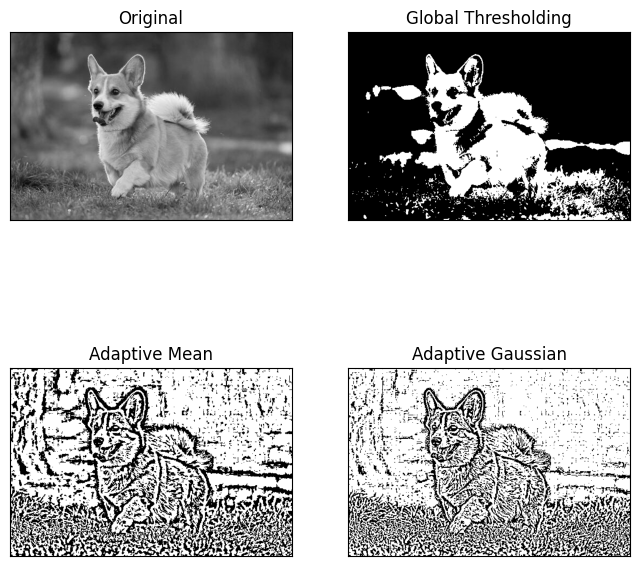

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv.imread("0_data/dog_img1.jpg")

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Global Thresholding
ret, thresh1 = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Adaptive Thresholding
thresh2 = cv.adaptiveThreshold(gray, 255,
                               cv.ADAPTIVE_THRESH_MEAN_C,
                               cv.THRESH_BINARY, 11, 2)

thresh3 = cv.adaptiveThreshold(gray, 255,
                               cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv.THRESH_BINARY, 11, 2)

# Titles and images
titles = ['Original', 'Global Thresholding',
          'Adaptive Mean', 'Adaptive Gaussian']

images = [gray, thresh1, thresh2, thresh3]

# Plot
plt.figure(figsize=(8, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()

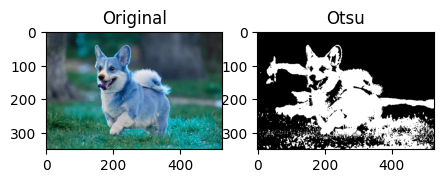

In [12]:
# Otsu's Binarization
import cv2 as cv
import matplotlib.pyplot as plt

# Read image
img = cv.imread("0_data/dog_img1.jpg")

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Otsu's Binarization
ret, thresh1 = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

titles = ['Original', 'Otsu']
data = [img, thresh1]

plt.figure(figsize = (5,5))

for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.title(titles[i])
    plt.imshow(data[i], cmap = 'gray')

plt.show()
